In [12]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from src.paths import resolve_repo_path
from src.utils import rank_logs
from src.stats import friedman_statistics, iman_davenport, eval_significance, critical_difference_nemenyi, critical_difference_bonferroni_dunn
from src.plot import draw_nemenyi_diagram, draw_bonferroni_dunn_diagram

In [13]:
with open(resolve_repo_path("logs/gradual.pkl"), "rb") as file:
    logs = pickle.load(file)

models = {log.model: 0 for log in logs}
synth_datasets = {log.dataset: 0 for log in logs}
N_MODELS = len(models)
N_DATASETS = len(synth_datasets)
print(f"""
MODELS: {N_MODELS}
N_DATASETS: {N_DATASETS}
""")


MODELS: 6
N_DATASETS: 33



In [14]:
params = ["performance", "memory", "time"]
results = []
for param in params:
    friedman_matrix = rank_logs(logs, param, models.keys(), synth_datasets.keys())
    results.append(friedman_matrix.rank(axis=1, ascending=True, method="average").mean())

results = pd.DataFrame(results, index=params)
stats_results = results.copy()
stats_results["fried_stats"] = results.apply(lambda x: friedman_statistics(x, N_DATASETS), axis=1)
stats_results["iman_davenport"] = stats_results["fried_stats"].apply(lambda x: iman_davenport(x, N_DATASETS, N_MODELS))
stats_results["significant"] = stats_results["iman_davenport"].apply(lambda x: eval_significance(x, N_MODELS, N_DATASETS, 0.05))

In [15]:
avg_memory_results = rank_logs(logs, "memory", models.keys(), synth_datasets.keys())/1e6
avg_memory_results = avg_memory_results.rank(axis=1, ascending=True, method="average").round(4)
avg_memory_results

,HATR (baseline),HTR-QO-0.25 (baseline),HTR-QO-0.5 (baseline),HTR-AQO-Triangular,HTR-AQO-Epanechnikov,HTR-AQO-Smooth
\n RandomRBF\n Seed Model = 168\n Seed Sample = 159\n N of classes: 2\n Change Speed: 0.3\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,1.0,6.0,5.0,2.0,3.0,4.0
\n RandomRBF\n Seed Model = 575\n Seed Sample = 380\n N of classes: 2\n Change Speed: 0.1\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,4.0,6.0,5.0,2.0,1.0,3.0
\n RandomRBF\n Seed Model = 386\n Seed Sample = 194\n N of classes: 2\n Change Speed: 0.2\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,4.0,6.0,5.0,1.0,3.0,2.0
\n RandomRBF\n Seed Model = 370\n Seed Sample = 730\n N of classes: 2\n Change Speed: 0.3\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,1.0,6.0,5.0,4.0,3.0,2.0
\n RandomRBF\n Seed Model = 489\n Seed Sample = 785\n N of classes: 2\n Change Speed: 0.3\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,4.0,6.0,5.0,3.0,1.0,2.0
\n RandomRBF\n Seed Model = 21\n Seed Sample = 711\n N of classes: 2\n Change Speed: 0.3\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,4.0,6.0,5.0,3.0,2.0,1.0
\n RandomRBF\n Seed Model = 862\n Seed Sample = 107\n N of classes: 2\n Change Speed: 0.2\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,4.0,6.0,5.0,2.0,1.0,3.0
\n RandomRBF\n Seed Model = 65\n Seed Sample = 644\n N of classes: 2\n Change Speed: 0.1\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,4.0,6.0,5.0,3.0,2.0,1.0
\n RandomRBF\n Seed Model = 324\n Seed Sample = 577\n N of classes: 2\n Change Speed: 0.1\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,4.0,6.0,5.0,1.0,2.0,3.0
\n RandomRBF\n Seed Model = 816\n Seed Sample = 417\n N of classes: 2\n Change Speed: 0.3\n N of features: 20\n N of centroids: 40\n N of drift centroids: 40\n,1.0,6.0,5.0,3.0,4.0,2.0


In [16]:
import seaborn as sns

<Axes: >

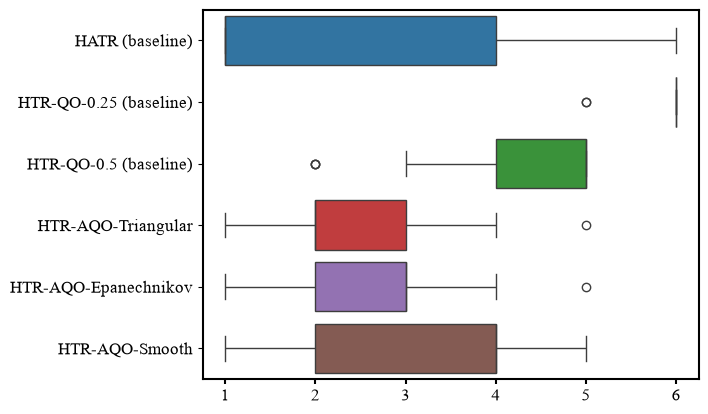

In [17]:
sns.boxplot(data=avg_memory_results, orient="y")